# House Price Prediction – End-to-End Machine Learning Project

This notebook demonstrates a complete regression workflow:

1. Import libraries
2. Load and inspect the dataset
3. Perform exploratory data analysis
4. Clean and prepare data
5. Split training and testing data
6. Build a preprocessing and regression pipeline
7. Train the model
8. Evaluate model performance
9. Compare actual and predicted prices
10. Make a new prediction
11. Save the trained model


## 1. Import Required Libraries

Run the installation command only when the libraries are not already installed.


In [ ]:
# Uncomment and run this line when packages are missing:
# !pip install pandas numpy matplotlib scikit-learn joblib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)


## 2. Load the Dataset


In [2]:
data = pd.read_csv("house_price_ml_dataset.csv")
data.head()


,property_id,location,property_type,bedrooms,bathrooms,area_sqft,age_years,distance_city_centre_km,has_garden,has_garage,nearby_school_rating,crime_rate_index,price_gbp
0,1,Manchester,Apartment,6,3,1551,28,4.6,0,0,3.8,12.2,471000
1,2,Leeds,Terraced,5,1,2099,25,21.6,1,0,3.3,29.5,511000
2,3,Birmingham,Detached,3,2,1068,27,28.7,1,0,2.3,16.8,372000
3,4,Liverpool,Apartment,6,4,2148,15,29.2,1,0,3.7,68.1,531000
4,5,Leeds,Apartment,1,1,846,10,25.7,0,1,2.8,54.5,210000


## 3. Inspect the Dataset


In [3]:
print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())


Dataset shape: (300, 13)

Column names:
['property_id', 'location', 'property_type', 'bedrooms', 'bathrooms', 'area_sqft', 'age_years', 'distance_city_centre_km', 'has_garden', 'has_garage', 'nearby_school_rating', 'crime_rate_index', 'price_gbp']


In [25]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_id              300 non-null    int64  
 1   location                 300 non-null    object 
 2   property_type            300 non-null    object 
 3   bedrooms                 300 non-null    int64  
 4   bathrooms                300 non-null    int64  
 5   area_sqft                300 non-null    int64  
 6   age_years                300 non-null    int64  
 7   distance_city_centre_km  300 non-null    float64
 8   has_garden               300 non-null    int64  
 9   has_garage               300 non-null    int64  
 10  nearby_school_rating     300 non-null    float64
 11  crime_rate_index         300 non-null    float64
 12  price_gbp                300 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 30.6+ KB


In [26]:
data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
property_id,300.0,NaN,NaN,NaN,150.5,86.746758,1.0,75.75,150.5,225.25,300.0
location,300,8,Birmingham,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,300,4,Semi-Detached,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,300.0,NaN,NaN,NaN,3.433333,1.71133,1.0,2.0,3.0,5.0,6.0
bathrooms,300.0,NaN,NaN,NaN,2.03,1.067504,1.0,1.0,2.0,3.0,4.0
area_sqft,300.0,NaN,NaN,NaN,1466.22,549.52582,556.0,1009.5,1410.5,1788.0,2912.0
age_years,300.0,NaN,NaN,NaN,51.053333,28.254052,0.0,27.0,52.0,73.0,100.0
distance_city_centre_km,300.0,NaN,NaN,NaN,15.570333,8.674413,1.0,8.575,15.05,23.6,29.9
has_garden,300.0,NaN,NaN,NaN,0.503333,0.500824,0.0,0.0,1.0,1.0,1.0
has_garage,300.0,NaN,NaN,NaN,0.49,0.500735,0.0,0.0,0.0,1.0,1.0


## 4. Check Missing Values and Duplicates


In [24]:
print("Missing values:")
print(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())


Missing values:
property_id                0
location                   0
property_type              0
bedrooms                   0
bathrooms                  0
area_sqft                  0
age_years                  0
distance_city_centre_km    0
has_garden                 0
has_garage                 0
nearby_school_rating       0
crime_rate_index           0
price_gbp                  0
dtype: int64

Duplicate rows: 0


In [27]:
# Remove duplicate rows if any exist
data = data.drop_duplicates().copy()


## 5. Exploratory Data Analysis

The charts below help us understand price distribution and important relationships.


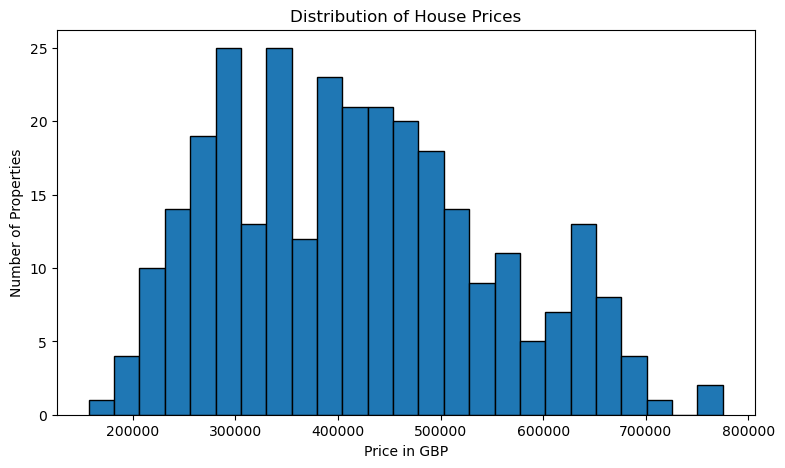

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(data["price_gbp"], bins=25, edgecolor="black")
plt.title("Distribution of House Prices")
plt.xlabel("Price in GBP")
plt.ylabel("Number of Properties")
plt.show()


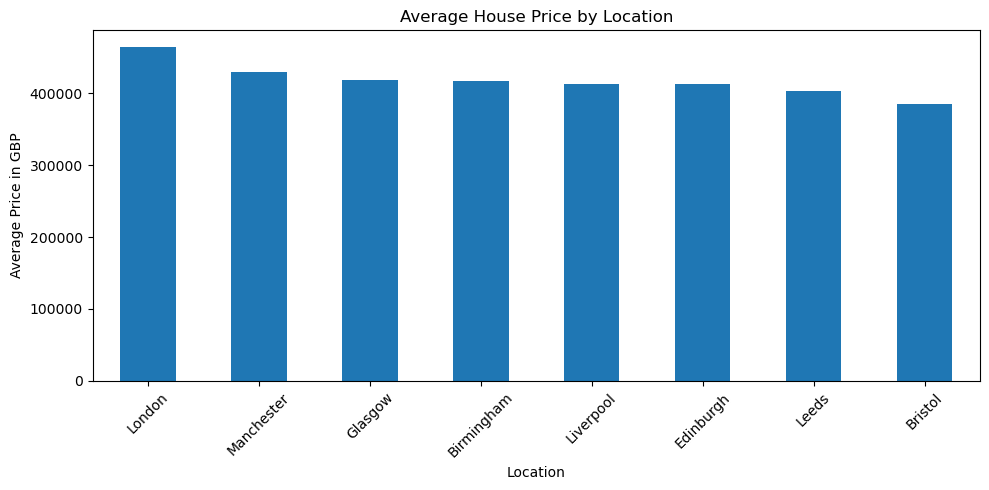

In [28]:
location_prices = (
    data.groupby("location")["price_gbp"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
location_prices.plot(kind="bar")
plt.title("Average House Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price in GBP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


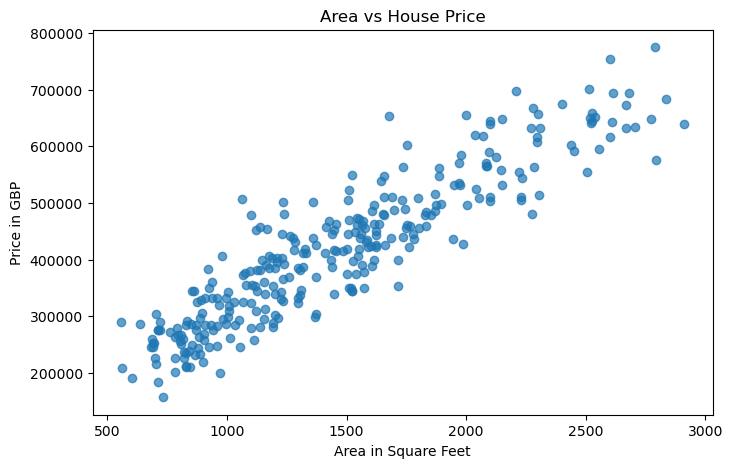

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(data["area_sqft"], data["price_gbp"], alpha=0.7)
plt.title("Area vs House Price")
plt.xlabel("Area in Square Feet")
plt.ylabel("Price in GBP")
plt.show()


## 6. Define Features and Target

`price_gbp` is the value the model must predict.

`property_id` is only an identifier, so it is removed from the model features.


In [29]:
X = data.drop(columns=["price_gbp", "property_id"])
y = data["price_gbp"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Features shape: (300, 11)
Target shape: (300,)


,location,property_type,bedrooms,bathrooms,area_sqft,age_years,distance_city_centre_km,has_garden,has_garage,nearby_school_rating,crime_rate_index
0,Manchester,Apartment,6,3,1551,28,4.6,0,0,3.8,12.2
1,Leeds,Terraced,5,1,2099,25,21.6,1,0,3.3,29.5
2,Birmingham,Detached,3,2,1068,27,28.7,1,0,2.3,16.8
3,Liverpool,Apartment,6,4,2148,15,29.2,1,0,3.7,68.1
4,Leeds,Apartment,1,1,846,10,25.7,0,1,2.8,54.5


## 7. Identify Categorical and Numerical Columns


In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)
print("Number of categorical columns:",len(categorical_columns))


Categorical columns: ['location', 'property_type']
Numerical columns: ['bedrooms', 'bathrooms', 'area_sqft', 'age_years', 'distance_city_centre_km', 'has_garden', 'has_garage', 'nearby_school_rating', 'crime_rate_index']


## 8. Split Training and Testing Data


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 240
Testing rows: 60


## 9. Create the Preprocessing and Model Pipeline

- `OneHotEncoder` converts text columns such as location and property type into numbers.
- `StandardScaler` scales numerical features.
- `LinearRegression` predicts the house price.


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Train the Model


In [17]:
model.fit(X_train, y_train)
print("Model training completed successfully.")


Model training completed successfully.


## 11. Make Predictions


In [18]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": np.round(y_pred, 2),
    "Difference": np.round(y_test.values - y_pred, 2)
})

results.head(10)


,Actual Price,Predicted Price,Difference
0,257000,266578.02,-9578.02
1,402000,387093.41,14906.59
2,389000,399131.66,-10131.66
3,633000,647371.97,-14371.97
4,275000,275656.53,-656.53
5,390000,385317.95,4682.05
6,617000,618650.67,-1650.67
7,531000,522357.86,8642.14
8,324000,311877.25,12122.75
9,251000,237105.01,13894.99


## 12. Evaluate Model Performance


In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: £{mae:,.2f}")
print(f"Root Mean Squared Error: £{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: £8,917.27
Root Mean Squared Error: £10,417.72
R² Score: 0.9937


### Understanding the metrics

- **MAE:** Average prediction error in pounds.
- **RMSE:** Penalizes larger prediction errors.
- **R²:** Measures how much of the price variation is explained by the model. A value closer to 1 is better.


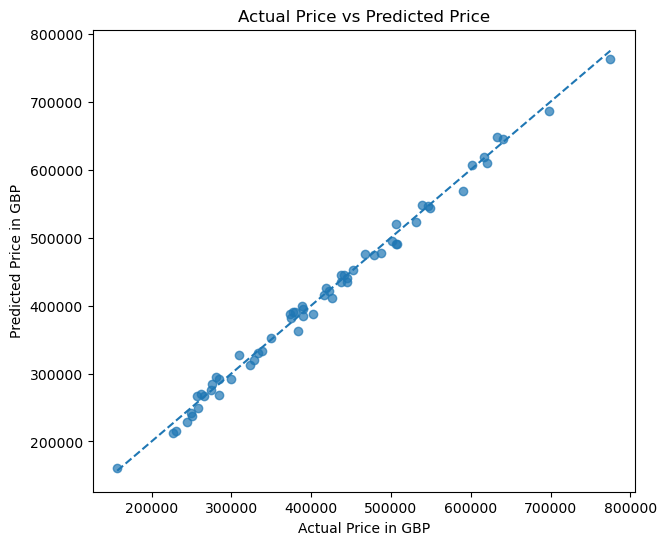

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price in GBP")
plt.ylabel("Predicted Price in GBP")
plt.show()


## 13. Predict the Price of a New Property


In [21]:
new_property = pd.DataFrame({
    "location": ["Manchester"],
    "property_type": ["Semi-Detached"],
    "bedrooms": [3],
    "bathrooms": [2],
    "area_sqft": [1450],
    "age_years": [12],
    "distance_city_centre_km": [6.5],
    "has_garden": [1],
    "has_garage": [1],
    "nearby_school_rating": [4.2],
    "crime_rate_index": [24.0]
})

predicted_price = model.predict(new_property)[0]

print(f"Predicted house price: £{predicted_price:,.2f}")


Predicted house price: £494,534.04


## 14. Save the Trained Model


In [22]:
joblib.dump(model, "house_price_model.pkl")
print("Model saved as house_price_model.pkl")


Model saved as house_price_model.pkl


## 15. Load and Test the Saved Model


In [23]:
loaded_model = joblib.load("house_price_model.pkl")
loaded_prediction = loaded_model.predict(new_property)[0]

print(f"Prediction from loaded model: £{loaded_prediction:,.2f}")


Prediction from loaded model: £494,534.04


## Next Step

Run the included Streamlit application with:

```bash
streamlit run app.py
```

The app loads `house_price_model.pkl` and provides a form for predicting house prices.
